In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

In [11]:
titanic=sns.load_dataset("titanic")
features=["pclass","sex","fare","embarked","age"]
target=["survived"]

# Handle Missing Data
imp_median = SimpleImputer(strategy="median")
titanic[["age"]]=imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]]=imp_freq.fit_transform(titanic[["embarked"]])

# Encoding
le=LabelEncoder()
titanic["sex"]=le.fit_transform(titanic["sex"])
titanic["embarked"]=le.fit_transform(titanic["embarked"])

X = titanic[features]
y = titanic["survived"]

In [12]:
# train test split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.3,random_state=42
)

In [13]:
# Decision Tree
model = DecisionTreeClassifier()

model. fit(X_train, y_train)

y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

print("Training accuracy: ", accuracy_score(y_train, y_pred_train)*100, "%")
print("Testing accuracy: ", accuracy_score(y_test, y_pred_test)*100, "%")

# OVERFITIING

Training accuracy:  97.91332263242376 %
Testing accuracy:  75.74626865671642 %


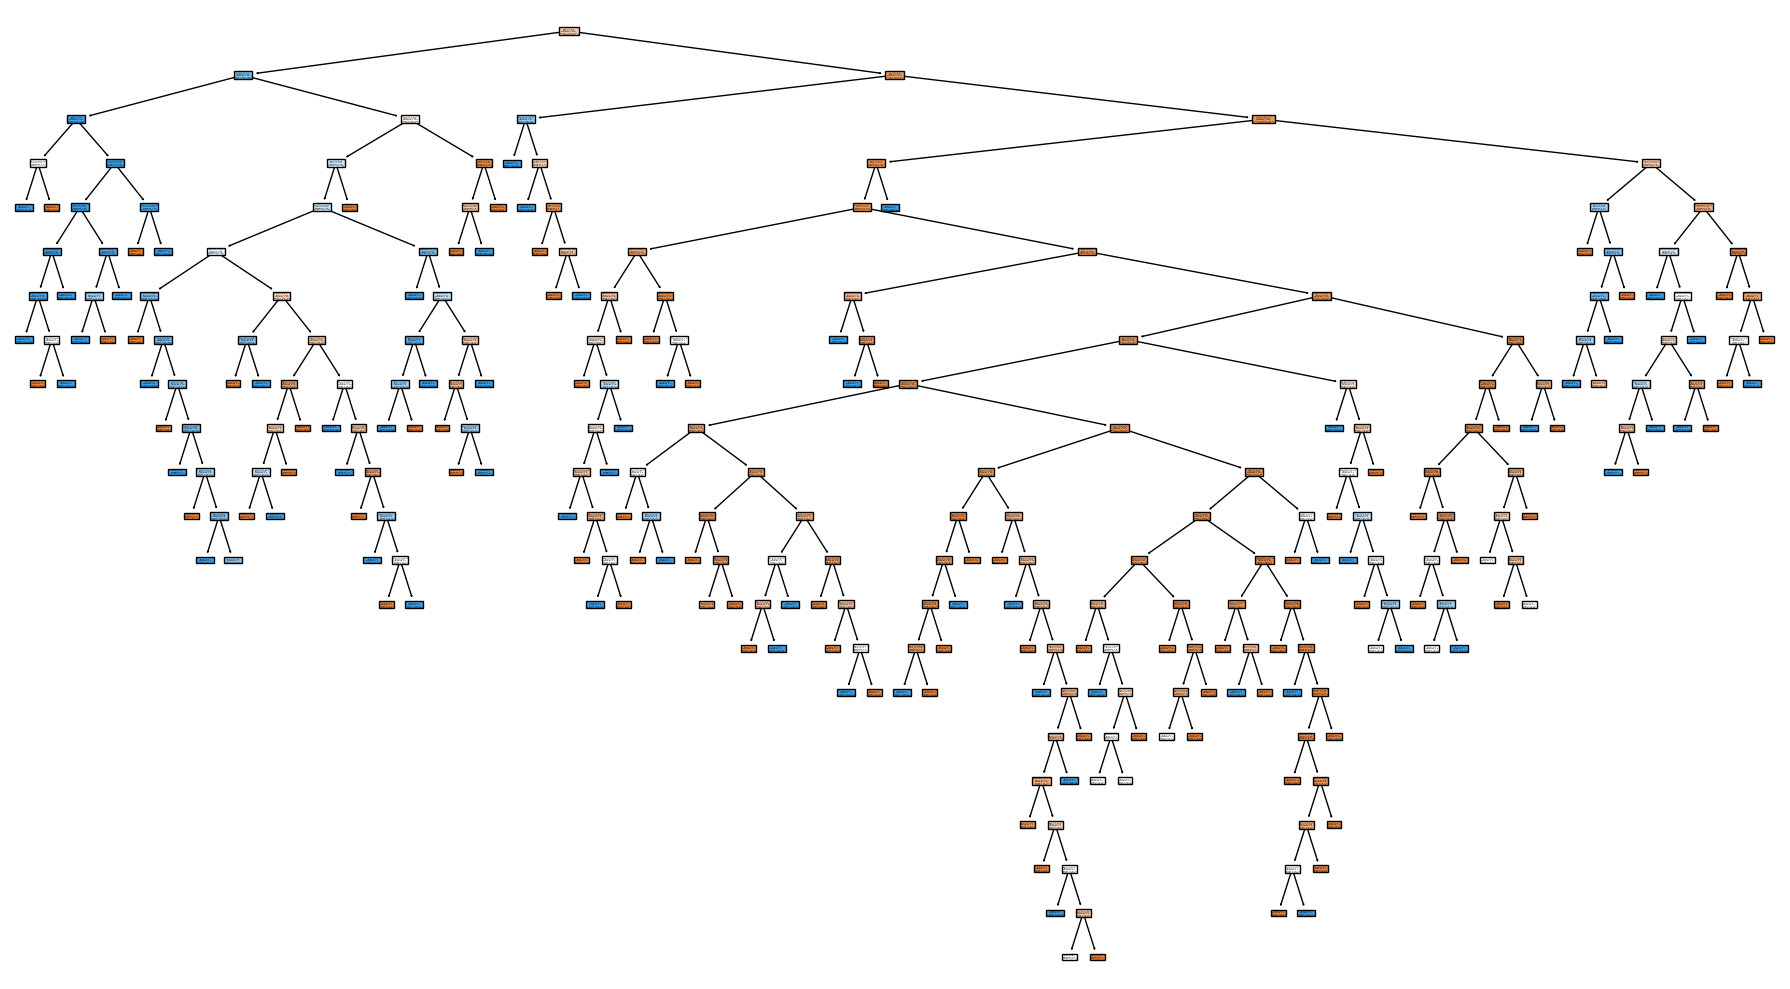

In [14]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died","Survivied"],
    filled=True
)
plt.tight_layout()

In [17]:
# Random forest classifier
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(

    n_estimators=401,
    oob_score=True,
    max_depth=4
)

model=rf.fit(X_train,y_train)
y_pred=model.predict(X_test)
print("OOB score : ",model.oob_score_)
print("testing accuracy : ",accuracy_score(y_test,y_pred))

OOB score :  0.8234349919743178
testing accuracy :  0.8171641791044776


In [19]:
# Bagging Classifier

from sklearn.ensemble import BaggingClassifier

base_model = DecisionTreeClassifier()

bagging = BaggingClassifier(
    base_model,
    n_estimators=201
)
bagging.fit(X_train, y_train)

y_pred = bagging.predict(X_test)


print("accuracy: ", accuracy_score(y_test, y_pred)*100, "%")

accuracy:  76.49253731343283 %


In [20]:
from sklearn.linear_model import LogisticRegression

base_model = LogisticRegression(max_iter=1000)

bagging = BaggingClassifier(
    base_model,
    n_estimators=201
)
bagging.fit(X_train, y_train)

y_pred = bagging.predict(X_test)


print("accuracy: ", accuracy_score(y_test, y_pred)*100, "%")

accuracy:  79.8507462686567 %


In [ ]:
#assignment pending